In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pytest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


In [4]:
#Load datasets for EDA

df = pd.read_csv('E:/Downloads/boston.csv')

#data loaded successfully

In [5]:
#Metadata

print ("\n Data Info: ")
df.info()


 Data Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [7]:
#basic Statistics

print ("\n Stats: ")
df.describe()



 Stats: 


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [8]:
#Check for null values
print ("\n Null Values: ")
print (df.isnull().sum())


 Null Values: 
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [9]:
#check for duplicates
print ("\n Duplicates: ")
print ("\n Duplicates: ", df.duplicated().sum())



 Duplicates: 

 Duplicates:  0


In [10]:
#shownig the first 5 rows
print ("Printing the first 5 rows: ")
print (df.head())

Printing the first 5 rows: 
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [11]:
#printing last 5 rows

print ("The last 5 rows: ")
print (df.tail())


The last 5 rows: 
        CRIM   ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
501  0.06263  0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273.0   
502  0.04527  0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273.0   
503  0.06076  0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273.0   
504  0.10959  0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273.0   
505  0.04741  0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273.0   

     PTRATIO       B  LSTAT  MEDV  
501     21.0  391.99   9.67  22.4  
502     21.0  396.90   9.08  20.6  
503     21.0  396.90   5.64  23.9  
504     21.0  393.45   6.48  22.0  
505     21.0  396.90   7.88  11.9  


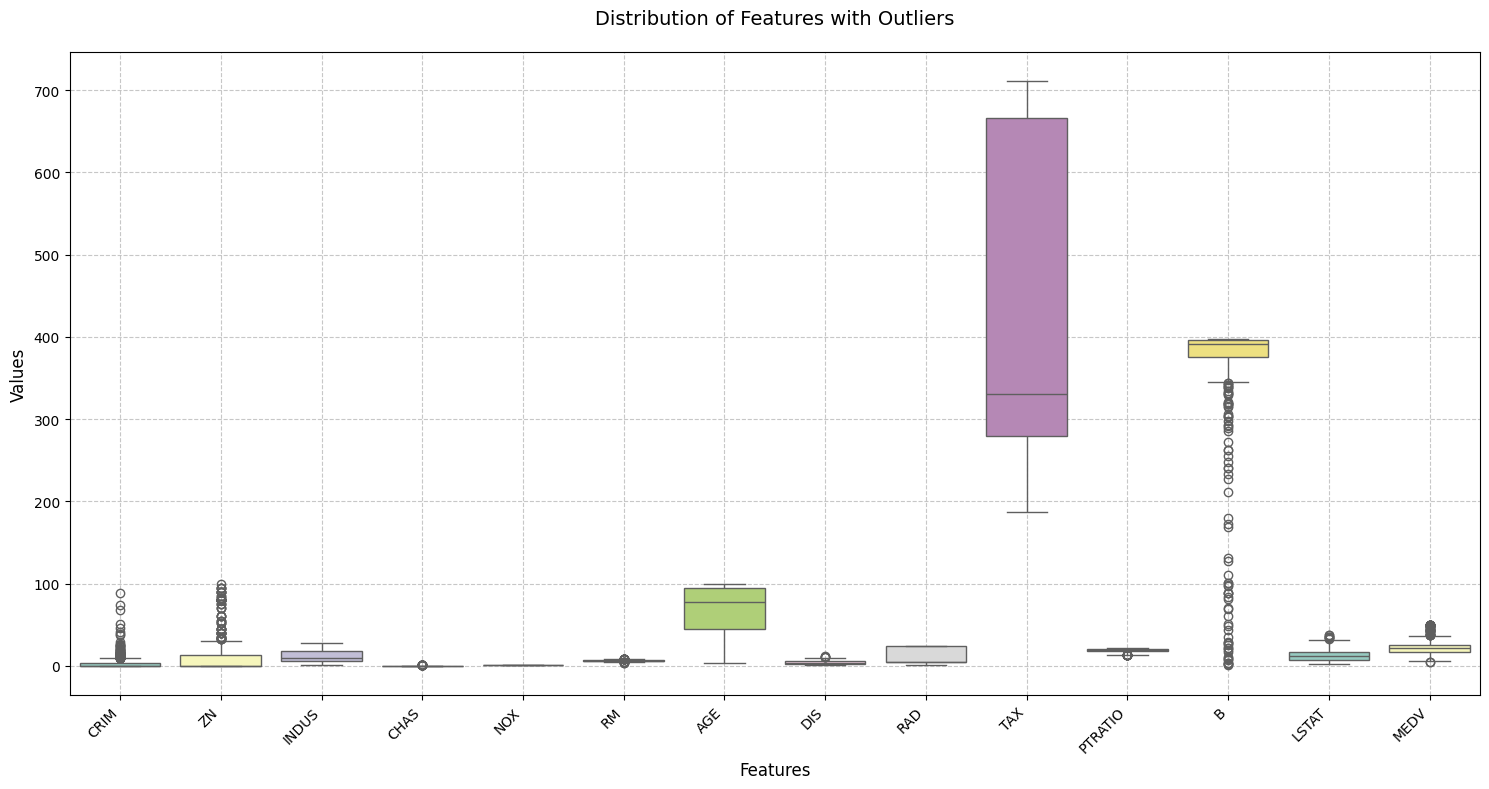

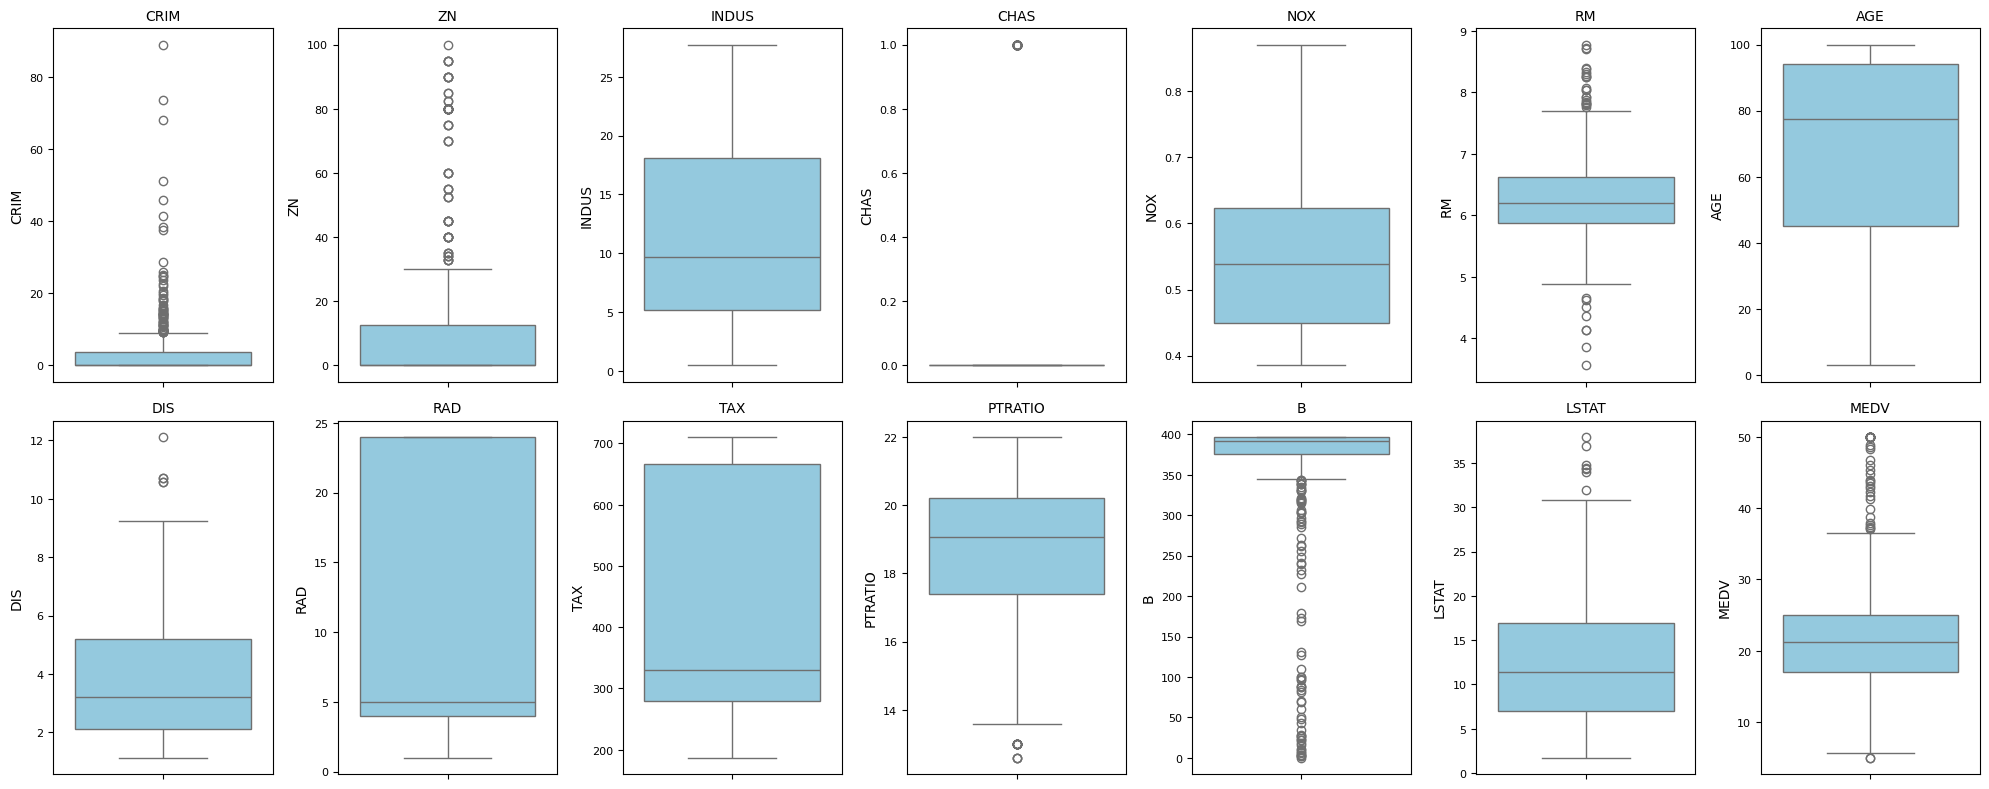

In [12]:
#Data Visualization since no null values or duplicates found
 
#box pot to identify outliers
# Large value ranges (e.g. CRIM, ZN) flatten smaller features, hiding outliers.

plt.figure(figsize=(15, 8))
sns.boxplot(data=df, palette='Set3')

# Customize the plot
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Features with Outliers', pad=20, fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#Large value ranges (e.g. CRIM, ZN) flatten smaller features, so individual boxplots are used.

fig, axes = plt.subplots(nrows=2, ncols=7, figsize=(20, 8))
axes = axes.flatten()

for idx, column in enumerate(df.columns):
    sns.boxplot(data=df[column], ax=axes[idx], color='skyblue')
    axes[idx].set_title(column, fontsize=10)
    axes[idx].tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

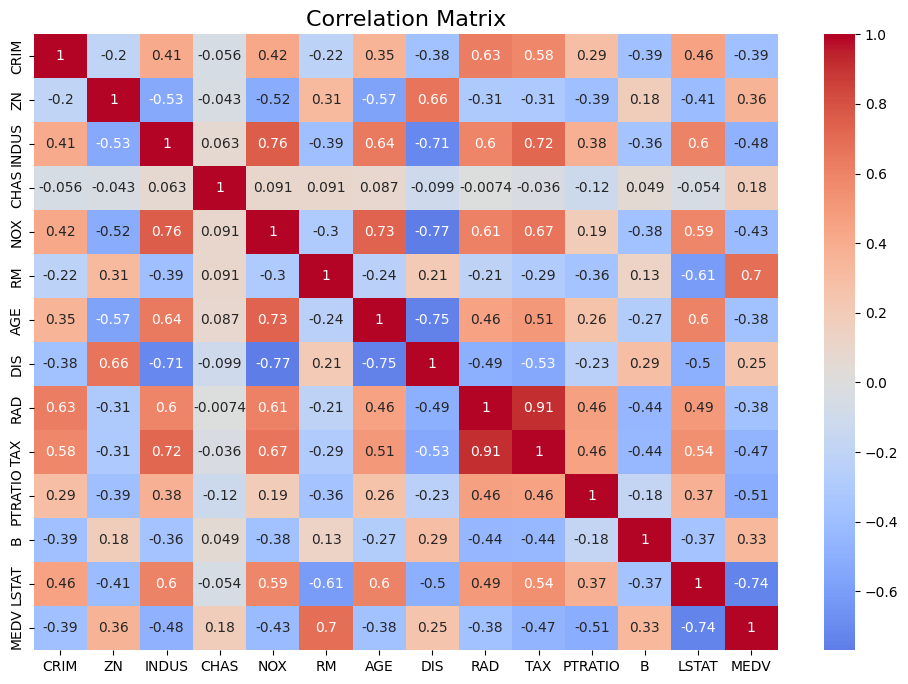

In [13]:
#correlation matrix to assist in Linear Regression

plt.figure (figsize=(12, 8))
sns.heatmap (df.corr(), annot = True, cmap = 'coolwarm', center=0)
plt.title ('Correlation Matrix', fontsize=16)
plt.tight_layout
plt.show()


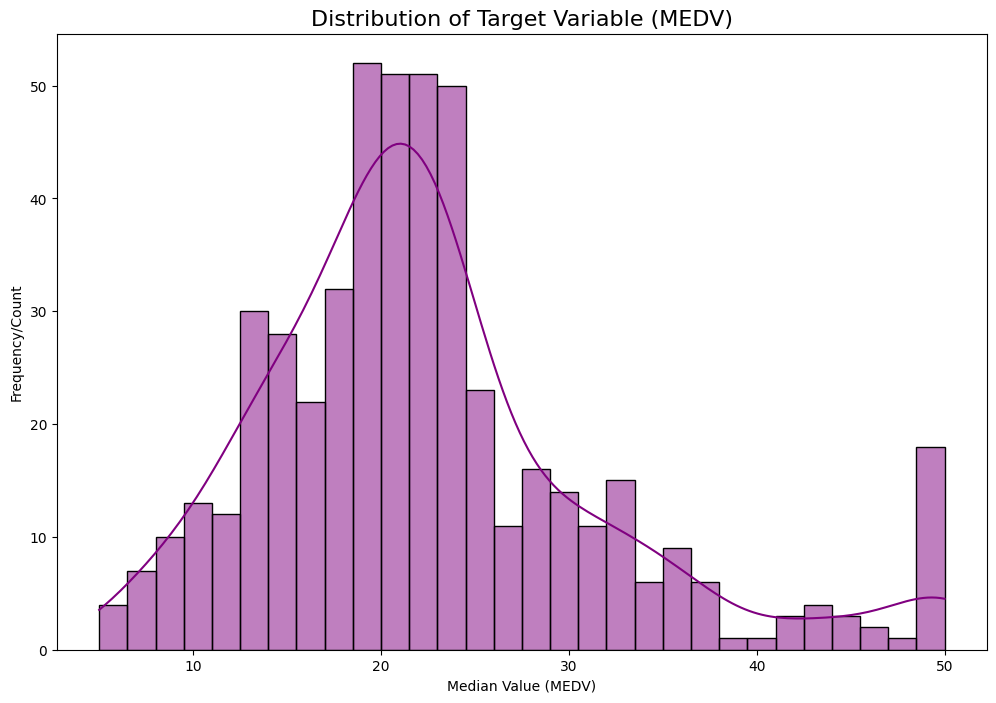

In [14]:
#Disttribution plot of target variable ('MEDV')

plt.figure (figsize=(12, 8))
sns.histplot (df['MEDV'], bins=30, kde=True, color='purple')
plt.title ('Distribution of Target Variable (MEDV)', fontsize=16)
plt.xlabel ('Median Value (MEDV)')
plt.ylabel ('Frequency/Count')
plt.show()

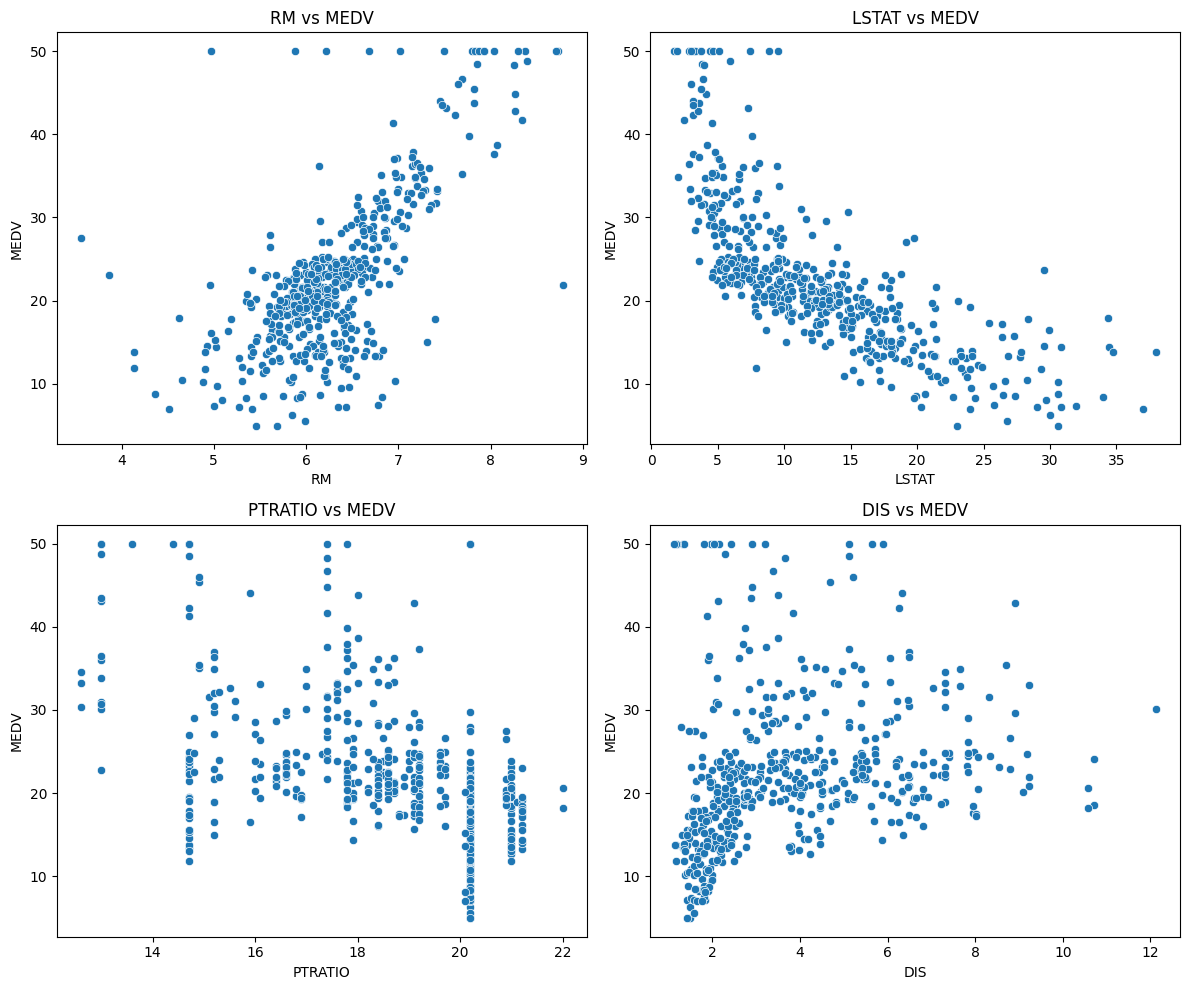

In [15]:
# Scatter plots of important features vs MEDV

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

features_to_plot = ['RM', 'LSTAT', 'PTRATIO', 'DIS']
for idx, feature in enumerate(features_to_plot):
    sns.scatterplot(data=df, x=feature, y='MEDV', ax=axes[idx])
    axes[idx].set_title(f'{feature} vs MEDV')

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

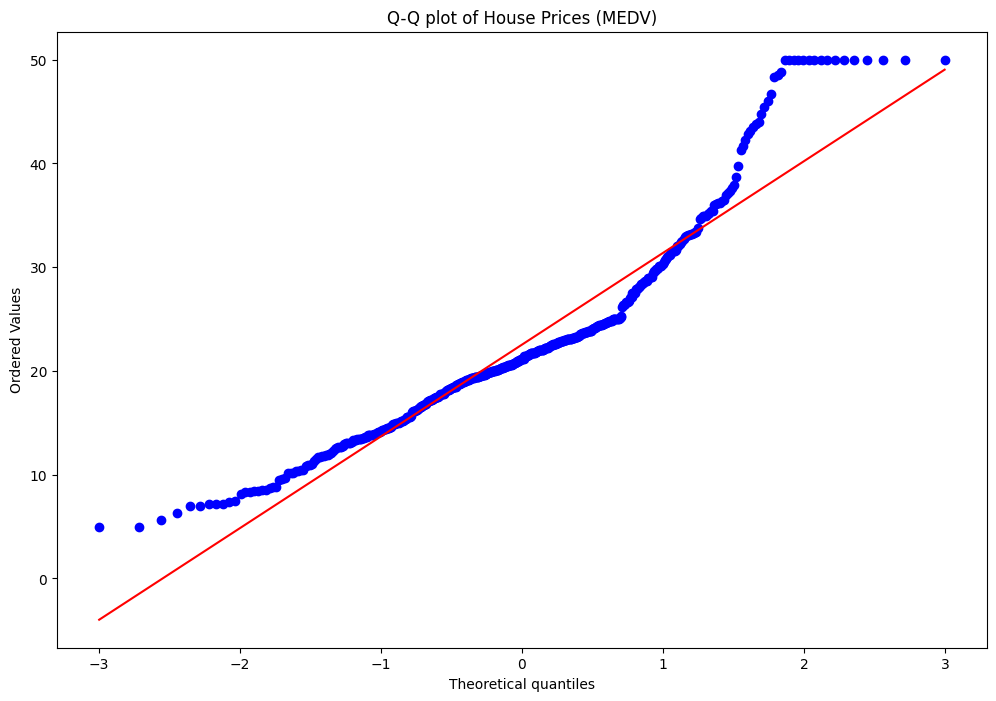

In [16]:
#Q-Q pliot to check normality of target variable (MEDV)
#if the points follow the diagonal line, the data is normally distributed.


plt.figure(figsize = (12,8))
stats.probplot(df['MEDV'], dist='norm', plot=plt)
plt.title("Q-Q plot of House Prices (MEDV)")
plt.show

In [17]:
#display correlation with MEDV (Target Variable)
# r > 0.7  strong correlation
# r ≈ 0.3–0.7  Moderate correlation
# r < 0.3  Weak correlation
# Features with moderate or strong correlation are useful for linear regression


print ("\n Correlation with MEDV: ")
correlations = df.corr()['MEDV'].sort_values(ascending=False)
print (correlations)


 Correlation with MEDV: 
MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


In [18]:
# checking for Feature Overlap using Variance Inflation Factor (VIF)

def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) 
                       for i in range(df.shape[1])]
    return vif_data

X = df.drop('MEDV', axis=1)
print("\nVIF Scores (>5 indicates high multicollinearity):")
print(calculate_vif(X))


VIF Scores (>5 indicates high multicollinearity):
    Feature        VIF
0      CRIM   2.100373
1        ZN   2.844013
2     INDUS  14.485758
3      CHAS   1.152952
4       NOX  73.894947
5        RM  77.948283
6       AGE  21.386850
7       DIS  14.699652
8       RAD  15.167725
9       TAX  61.227274
10  PTRATIO  85.029547
11        B  20.104943
12    LSTAT  11.102025


In [19]:
# Identify and handle outliers using InterQuartileRange method
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers)

# Check outliers in important features

important_features = ['RM', 'LSTAT', 'PTRATIO', 'DIS', 'MEDV']
print("\nNumber of outliers in important features:")
for feature in important_features:
    n_outliers = detect_outliers(df, feature)
    print(f"{feature}: {n_outliers} outliers")


Number of outliers in important features:
RM: 30 outliers
LSTAT: 7 outliers
PTRATIO: 15 outliers
DIS: 5 outliers
MEDV: 40 outliers


In [20]:
def remove_outliers(df, columns):
    df_clean = df.copy()
    for column in columns:
        Q1 = df_clean[column].quantile(0.25)
        Q3 = df_clean[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[column] >= lower_bound) & 
                           (df_clean[column] <= upper_bound)]
    return df_clean

# Remove outliers from important features
important_features = ['RM', 'LSTAT', 'PTRATIO', 'DIS', 'MEDV']
df_no_outliers = remove_outliers(df, important_features)

# Print the number of rows removed
print(f"Original dataset size: {len(df)}")
print(f"Dataset size after removing outliers: {len(df_no_outliers)}")
print(f"Number of rows removed: {len(df) - len(df_no_outliers)}")



Original dataset size: 506
Dataset size after removing outliers: 434
Number of rows removed: 72


In [21]:
X = df_no_outliers.drop('MEDV', axis=1)# input or features all data apart from target variable (price)
y = df_no_outliers['MEDV'] # Target variable



In [22]:
X_train, X_test, y_train, y_test = train_test_split(  #splitting for training and testing
X, y, test_size=0.2, random_state=42)   #20% test size, 80% train size
                                         # random state for reproducibility

In [23]:
scaler = StandardScaler() #features scaled so that all are on the same scale
X_train = scaler.fit_transform(X_train) #else tax or zn with heavy numbers will dominate model
X_test = scaler.transform(X_test)


In [24]:
model = LinearRegression() #Linear regression model initiated (empty)
model.fit(X_train, y_train) #model trained on training data .fit helps find the best fit 


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
y_pred = model.predict(X_test)  # predictions made on test data
print (y_pred)

[21.4581225  21.98980882 21.62729207 27.67821565 15.73747776 17.96281113
 22.23754285 24.10841647 13.4992463  22.57105067 17.68298969 21.47407247
 18.98412686 17.53371649 16.88436913 22.39263907 22.73784541 26.34477884
 24.87434013 11.52238126 19.32522034 15.80468379 18.25633138 15.78691694
 26.95975512 14.96415126 22.5357233  16.51358714 14.79714972 24.13497936
 23.11232339 22.35330391 21.54252922 18.50921248 19.60507462 24.47292244
 20.30599059 29.79796854 30.80070933 13.22811108 11.99398992 21.40164306
 19.81568274 26.9138391  24.60641308 15.01690058 13.76067871 23.05429073
 21.03323888 26.05335804 19.98210748 21.62384627 30.03128033 22.2879186
 27.12599362 14.22028534 14.7493882  22.36426252 29.63489608 27.62372888
 27.87782185 24.3573186  23.11930861 17.19748689 14.95582834 16.05346764
 16.75239639 24.36177093 21.65343011 14.1167373  25.39543747 11.86511266
 14.99712033 21.56840748 20.7310906  29.4824737  23.92121801 15.25636329
 18.99677621 25.16375923 20.72916824 24.43876025 20.

In [26]:
mse = mean_squared_error(y_test, y_pred) #MSE caluculated to evaluate model performance
                                         #diff bw actual and predicted values (lower the better)
r2 = r2_score(y_test, y_pred) # R² score calculated to evaluate model performance
                              # 0-1 (1 is perfect fit, 0 is no fit)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.2f}') 


Mean Squared Error: 5.68
R² Score: 0.83


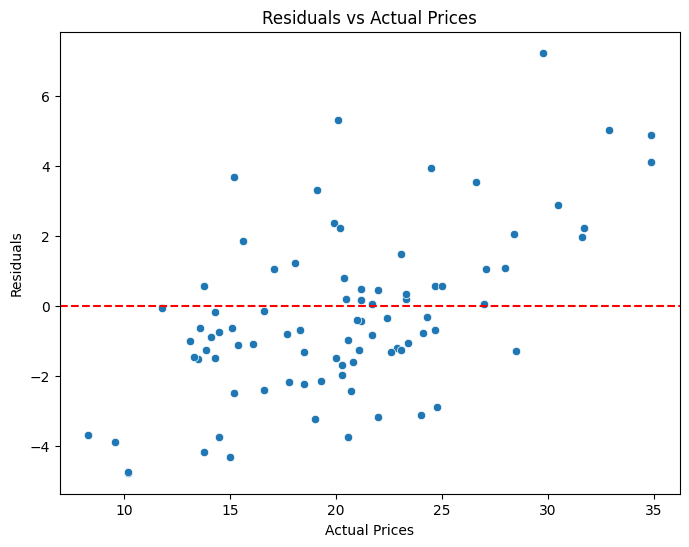

In [27]:
residuals = y_test - y_pred #residual = actual - predicted
# Plotting residuals to check for patterns          
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Residuals')
plt.title('Residuals vs Actual Prices')
plt.show()


In [28]:
coefficients = pd.DataFrame(model.coef_, index=df.columns[:-1], columns=['Coefficient'])
print(coefficients.sort_values(by='Coefficient', ascending=False))


         Coefficient
RAD         1.932746
RM          1.433154
B           0.758409
CHAS        0.375043
ZN          0.342034
INDUS       0.033508
AGE        -0.613912
CRIM       -0.954955
NOX        -1.113931
PTRATIO    -1.181650
DIS        -1.519111
TAX        -2.207461
LSTAT      -2.354745


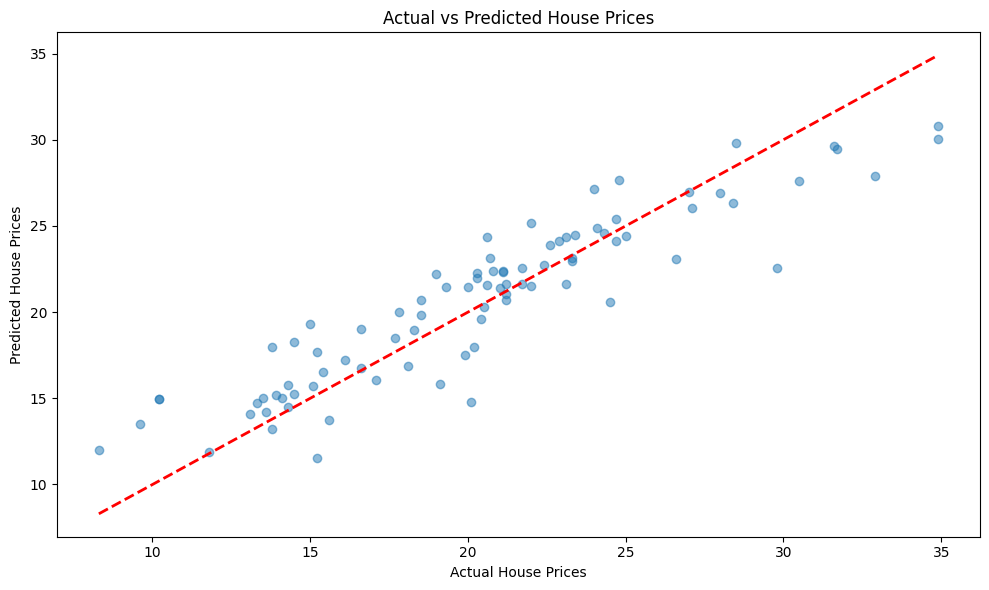

In [29]:
# Actual vs Predicted Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.show()